# **Traffic** Sign Classification using K-Nearest Neighbors (KNN)

## Project Objective
This project aims to classify traffic sign images into their respective classes using the K-Nearest Neighbors (KNN) algorithm.

## Import Libraries

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import seaborn as sns

## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Path Setup

In [4]:
base_path = '/content/drive/MyDrive/Traffic Sign Classification Project'
print(os.listdir(base_path))

['labels.csv', 'TEST', 'DATA', 'labels.gsheet', 'Traffic_Sign_Classification_KNN.ipynb']


In [5]:
#checking the dataset folders
data_path = os.path.join(base_path, 'DATA')
print("Number of class folders:", len(os.listdir(data_path)))
print(os.listdir(data_path)[:10])

Number of class folders: 58
['7', '6', '55', '8', '9', '57', '56', '53', '52', '50']


## Load Labels File

In [6]:
#csv Loading
labels_df = pd.read_csv(os.path.join(base_path, 'labels.csv'))
print(labels_df.head())
print("Total labels:", len(labels_df))

   ClassId                  Name
0        0   Speed limit (5km/h)
1        1  Speed limit (15km/h)
2        2  Speed limit (30km/h)
3        3  Speed limit (40km/h)
4        4  Speed limit (50km/h)
Total labels: 58


# **Dataset Exploration**

In [7]:
#checking a random folder from data
sample_class = os.listdir(data_path)[0]
sample_class_path = os.path.join(data_path, sample_class)

print("Sample class folder:", sample_class)
print("Number of images in this class:", len(os.listdir(sample_class_path)))
print("First 5 image files:", os.listdir(sample_class_path)[:5])

Sample class folder: 7
Number of images in this class: 152
First 5 image files: ['007_0033.png', '007_0069.png', '007_0067.png', '007_1_0026.png', '007_0013.png']


Image size: (103, 97)


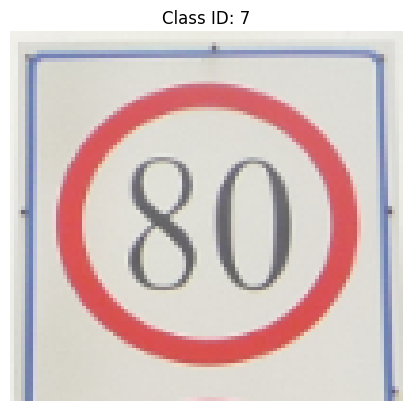

In [8]:
#displaying one sample image with its basic detail

sample_image_name = os.listdir(sample_class_path)[0]
sample_image_path = os.path.join(sample_class_path, sample_image_name)

img = Image.open(sample_image_path)
print("Image size:", img.size)

plt.imshow(img)
plt.title(f"Class ID: {sample_class}")
plt.axis('off')
plt.show()

In [9]:
#counting the no. of images in each class
class_counts = {}

for class_folder in os.listdir(data_path):
    class_folder_path = os.path.join(data_path, class_folder)
    if os.path.isdir(class_folder_path):
        class_counts[class_folder] = len(os.listdir(class_folder_path))

print("Total classes:", len(class_counts))
print("Sample class counts:", list(class_counts.items())[:10])

Total classes: 58
Sample class counts: [('7', 152), ('6', 78), ('55', 162), ('8', 8), ('9', 2), ('57', 6), ('56', 110), ('53', 2), ('52', 36), ('50', 56)]


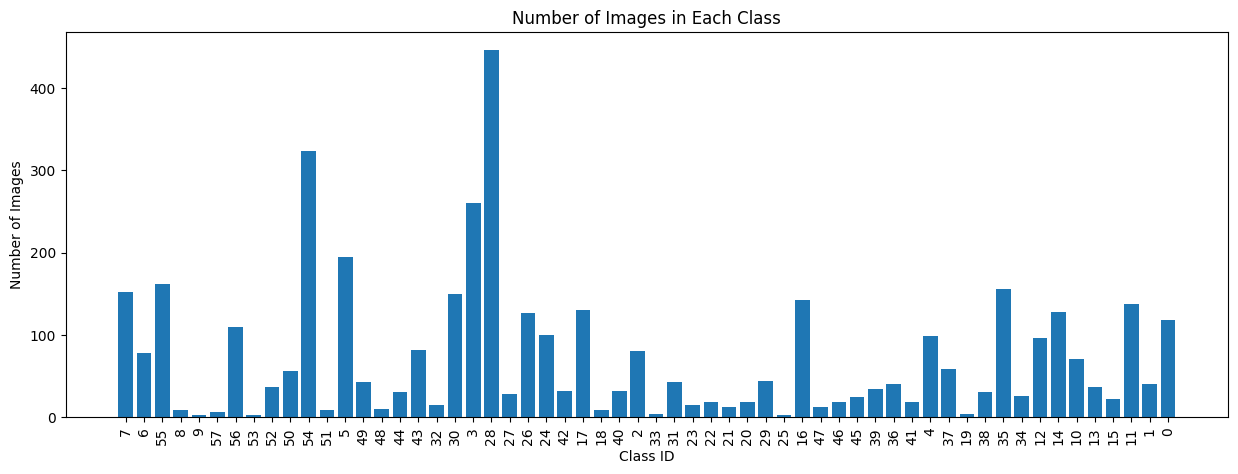

In [10]:
#visual representation of no.of images in each class

plt.figure(figsize=(15,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images in Each Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

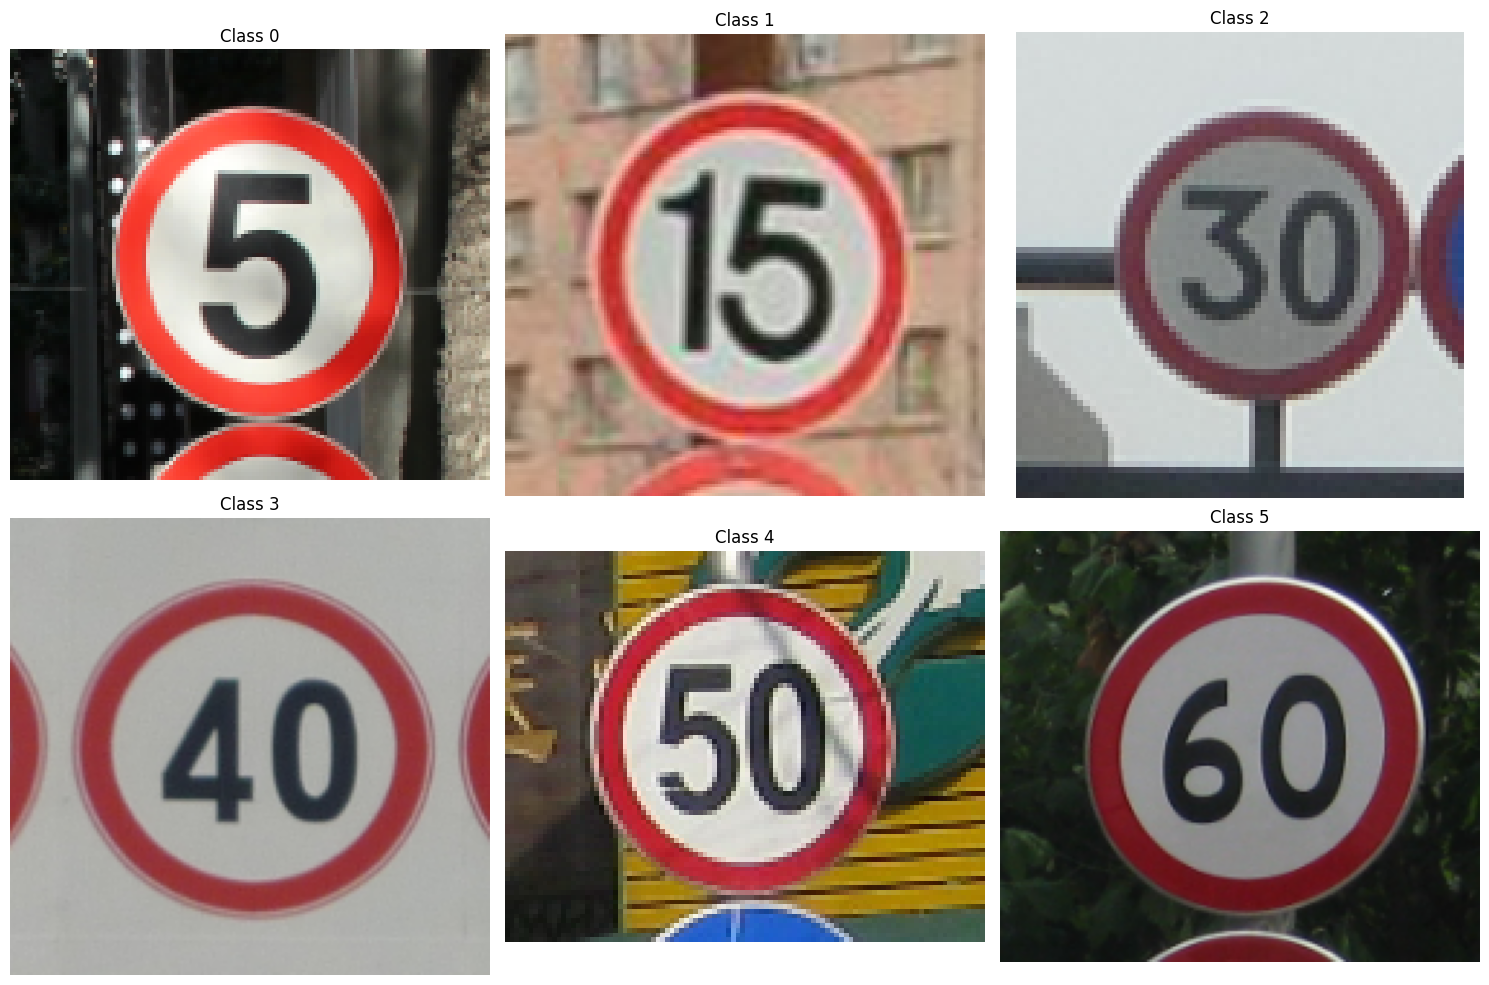

In [11]:
#displaying the images from each first 6 classes
plt.figure(figsize=(15,10))

class_folders = sorted(os.listdir(data_path), key=lambda x: int(x))

for i, class_folder in enumerate(class_folders[:6]):
    class_folder_path = os.path.join(data_path, class_folder)
    image_name = os.listdir(class_folder_path)[0]
    image_path = os.path.join(class_folder_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Class {class_folder}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Image Preprocessing**

In [12]:
#loading images and labels into arrays

images = []
labels = []
img_size = 32


In [13]:
#resizing image to 32*32
for class_folder in os.listdir(data_path):
    class_folder_path = os.path.join(data_path, class_folder)

    if os.path.isdir(class_folder_path):
        for image_name in os.listdir(class_folder_path):
            image_path = os.path.join(class_folder_path, image_name)

            try:
                img = Image.open(image_path).resize((img_size, img_size))
                img = np.array(img)

                images.append(img)
                labels.append(int(class_folder))
            except:
                pass

In [14]:
#inserting images into array

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

images = images / 255.0

images_flat = images.reshape(images.shape[0], -1)
print("Flattened image shape:", images_flat.shape)

Images shape: (4166, 32, 32, 3)
Labels shape: (4166,)
Flattened image shape: (4166, 3072)


In [15]:
images_flat = images.reshape(images.shape[0], -1)
print("Flattened image shape:", images_flat.shape)

Flattened image shape: (4166, 3072)


# **TRAIN TEST SPLIT**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images_flat, labels, test_size=0.2, random_state=42, stratify=labels
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3332, 3072)
X_test shape: (834, 3072)
y_train shape: (3332,)
y_test shape: (834,)


In [20]:
#checking best k value to use
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
for k in [1, 3, 5, 7]:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    acc = accuracy_score(y_test, y_pred_temp)
    print(f"k = {k}, Accuracy = {acc*100:.2f}%")

k = 1, Accuracy = 96.40%
k = 3, Accuracy = 80.22%
k = 5, Accuracy = 81.29%
k = 7, Accuracy = 78.42%


K=1 gives more accuracy than others

## **KNN Model Training**


In [21]:
#implimenting knn classifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [22]:
#checking the accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 96.40%


In [23]:
#assignng class names to class IDs

label_map = dict(zip(labels_df['ClassId'], labels_df['Name']))
print(label_map[0])#sample output

Speed limit (5km/h)


## Sample Predictions

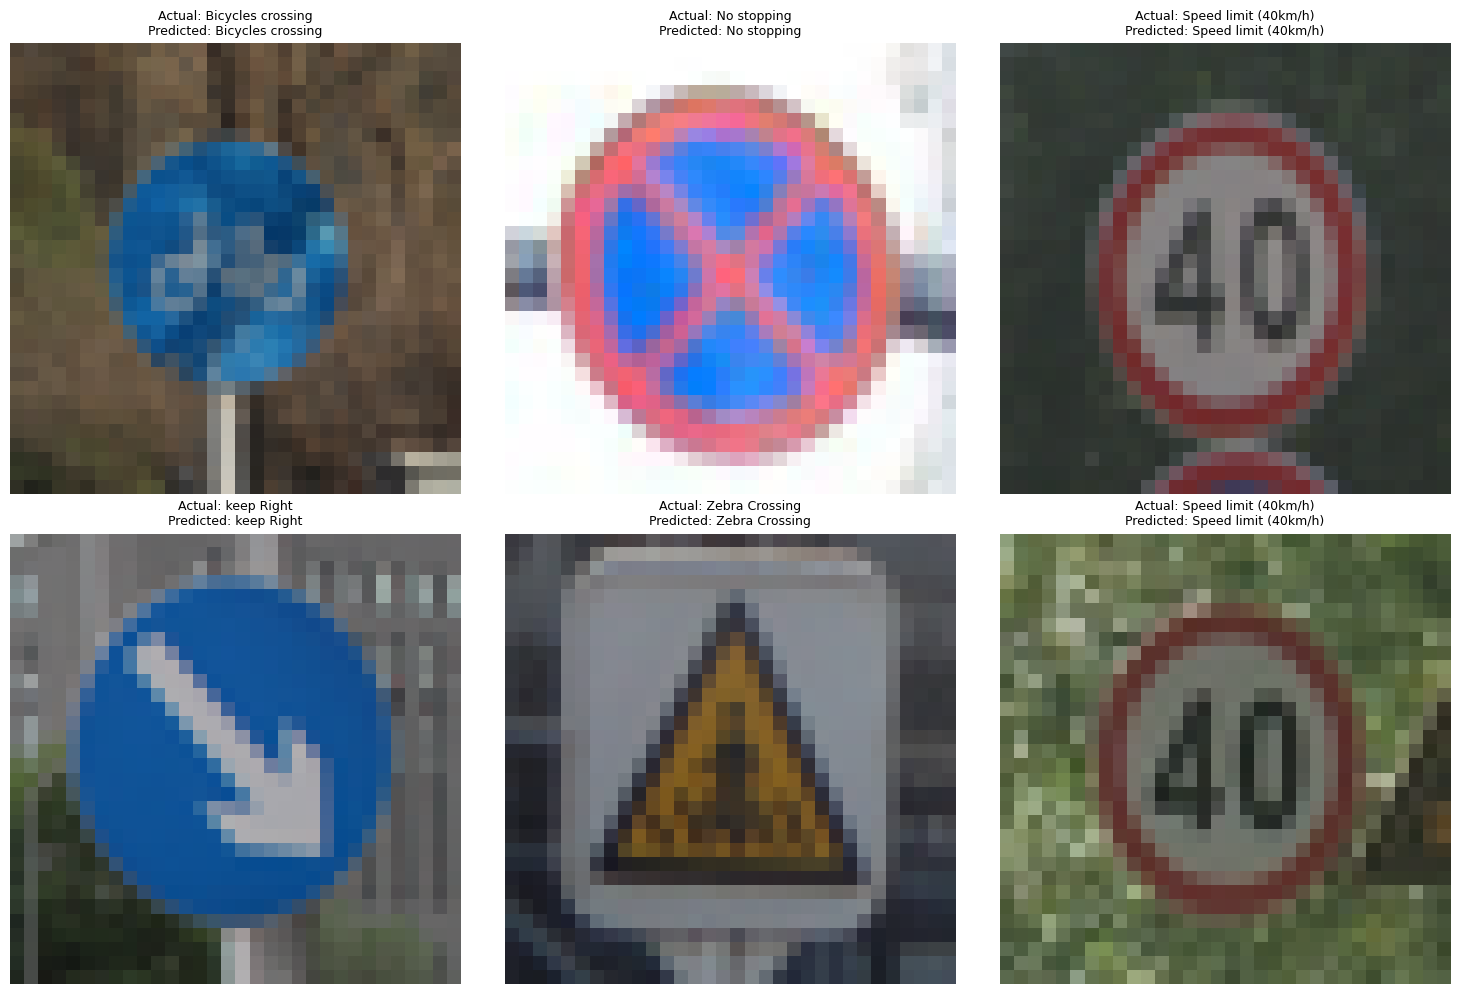

In [24]:
#testing model on 6 images
plt.figure(figsize=(15,10))
for i in range(6):
    img = X_test[i].reshape(32, 32, 3)

    actual_label = label_map[y_test[i]]
    predicted_label = label_map[y_pred[i]]

    plt.subplot(2, 3,i+1)
    plt.imshow(img)
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# **EVALUATION**

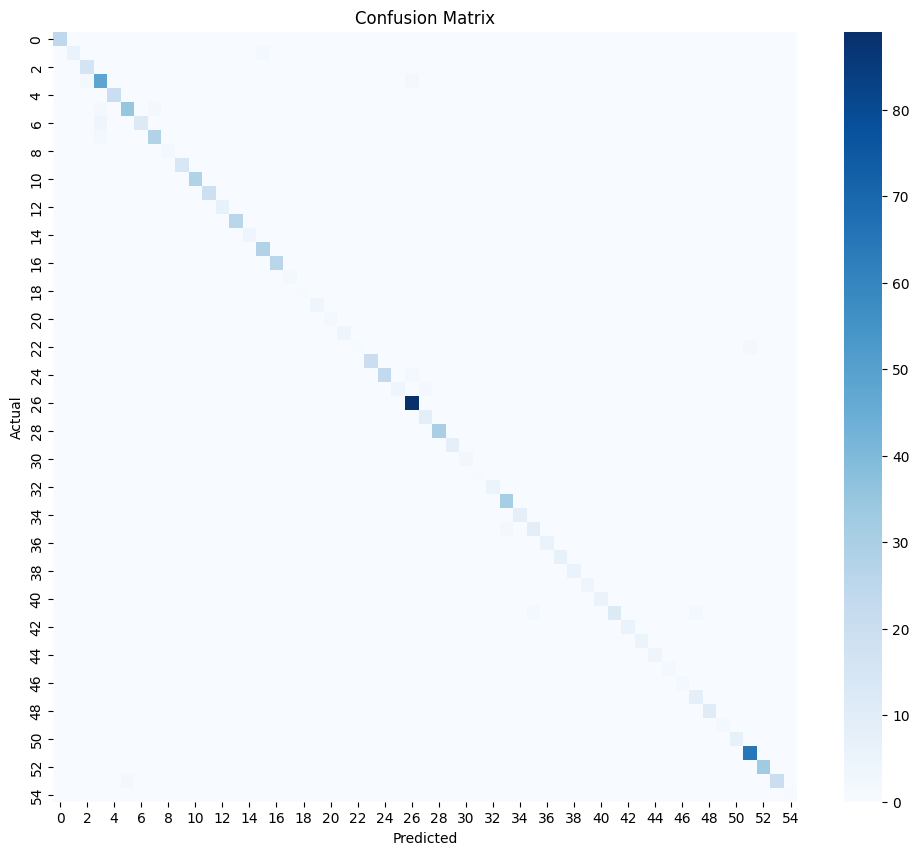

In [25]:
#visual represention of prediction
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Real-Time Image Prediction**

In [27]:

#uploading images form testing dataset
from google.colab import files
uploaded = files.upload()


Saving 010_0002_j.png to 010_0002_j.png


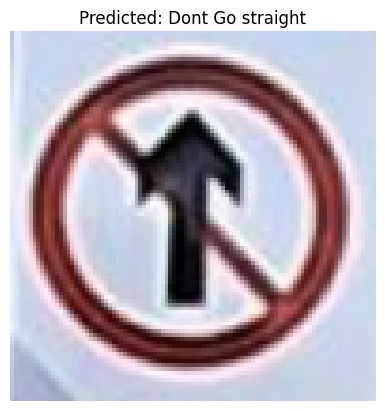

Predicted Class ID: 10
Predicted Class Name: Dont Go straight


In [28]:
uploaded_image_name = list(uploaded.keys())[0]

img = Image.open(uploaded_image_name).convert('RGB')
img = img.resize((32, 32))
img_array = np.array(img) / 255.0
img_flat = img_array.reshape(1, -1)

prediction = knn.predict(img_flat)[0]
predicted_label = label_map[prediction]

plt.imshow(Image.open(uploaded_image_name))
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()

print("Predicted Class ID:", prediction)
print("Predicted Class Name:", predicted_label)

## Conclusion
The KNN model was successfully used to classify traffic sign images. The final model achieved high accuracy and demonstrated good performance on the test dataset.